In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# 1. CARGAR DATASET DE VIDEOJUEGOS 
df_vg = pd.read_csv('vgsales.csv')
df_vg['Year'] = pd.to_numeric(df_vg['Year'], errors='coerce')
df_vg = df_vg.dropna(subset=['Year'])
df_vg['Year'] = df_vg['Year'].astype(int)
print("--- Primeras 5 filas (Head) ---") #Inspeccion visual de los datos
display(df_vg.head())

--- Primeras 5 filas (Head) ---


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [3]:
print("\n--- Últimas 5 filas (Tail) ---")
display(df_vg.tail())


--- Últimas 5 filas (Tail) ---


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002,Platform,Kemco,0.01,0.00,0.0,0.0,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003,Shooter,Infogrames,0.01,0.00,0.0,0.0,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,Activision,0.00,0.00,0.0,0.0,0.01
16596,16599,Know How 2,DS,2010,Puzzle,7G//AMES,0.00,0.01,0.0,0.0,0.01
16597,16600,Spirits & Spells,GBA,2003,Platform,Wanadoo,0.01,0.00,0.0,0.0,0.01


In [4]:
print("\n--- Muestra Aleatoria (Sample) ---")
display(df_vg.sample(5))


--- Muestra Aleatoria (Sample) ---


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
12176,12178,R-Type Command,PSP,2007,Strategy,Rising Star Games,0.05,0.00,0.01,0.01,0.07
13633,13635,Company of Heroes: Tales of Valor,PC,2009,Strategy,THQ,0.00,0.03,0.00,0.01,0.04
15098,15101,ScrapLand,XB,2005,Action,Deep Silver,0.02,0.00,0.00,0.00,0.02
2373,2375,Phantasy Star Portable 2,PSP,2009,Role-Playing,Sega,0.08,0.11,0.62,0.06,0.88
12360,12362,Age of Empires Online,PC,2011,Strategy,Microsoft Game Studios,0.01,0.04,0.00,0.01,0.06


In [5]:
print("\n--- Resumen Estadístico Descriptivo (.describe) ---")
display(df_vg.describe())


--- Resumen Estadístico Descriptivo (.describe) ---


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16327.000000,16327.000000,16327.000000,16327.000000,16327.000000,16327.000000,16327.000000
mean,8292.868194,2006.406443,0.265415,0.147554,0.078661,0.048325,0.540232
std,4792.669778,5.828981,0.821591,0.508766,0.311557,0.189885,1.565732
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4136.500000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8295.000000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12441.500000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.480000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [6]:
# EXTRACCION DE METRICAS DESCRIPTIVAS JUEGOS
total_juegos = df_vg['Name'].nunique()
total_generos = df_vg['Genre'].nunique()
total_plataformas = df_vg['Platform'].nunique()

print("--- MÉTRICAS TOTALES DEL MERCADO ---")
print(f"1) Total de videojuegos analizados: {total_juegos}")
print(f"2) Total de géneros analizados: {total_generos} -> {df_vg['Genre'].unique()}")
print(f"3) Total de plataformas analizadas: {total_plataformas}")

--- MÉTRICAS TOTALES DEL MERCADO ---
1) Total de videojuegos analizados: 11360
2) Total de géneros analizados: 12 -> ['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Action' 'Fighting' 'Adventure' 'Strategy']
3) Total de plataformas analizadas: 31


--- MÉTRICAS TOTALES DEL MERCADO ---
1) Total de videojuegos analizados: 11360
2) Total de géneros analizados: 12 -> ['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Action' 'Fighting' 'Adventure' 'Strategy']
3) Total de plataformas analizadas: 31

In [7]:
# DESGLOCE DE VENTAS POR AÑO E INGRESOS POR REGION
regiones = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
ventas_por_año = df_vg.groupby('Year')[regiones].sum().reset_index()

print("--- Histórico de Ventas Desglosado por Región e Ingresos (Muestra últimos 10 años) ---")
display(ventas_por_año.tail(10))

--- Histórico de Ventas Desglosado por Región e Ingresos (Muestra últimos 10 años) ---


,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
29,2009,338.85,191.59,61.89,74.77,667.30
30,2010,304.24,176.73,59.49,59.90,600.45
31,2011,241.06,167.44,53.04,54.39,515.99
32,2012,154.96,118.78,51.74,37.82,363.54
33,2013,154.77,125.80,47.59,39.82,368.11
34,2014,131.97,125.65,39.46,40.02,337.05
35,2015,102.82,97.71,33.72,30.01,264.44
36,2016,22.66,26.76,13.70,7.75,70.93
37,2017,0.00,0.00,0.05,0.00,0.05
38,2020,0.27,0.00,0.00,0.02,0.29


In [9]:
# VIDEO JUEGOS MAS VENDIDOS
idx_juegos = df_vg.groupby('Year')['Global_Sales'].idxmax()
juegos_top_año = df_vg.loc[idx_juegos, ['Year', 'Name', 'Global_Sales']].sort_values('Year')

print("--- Videojuegos Más Vendidos por Año (Global) ---")
display(juegos_top_año.tail(10))

--- Videojuegos Más Vendidos por Año (Global) ---


,Year,Name,Global_Sales
3,2009,Wii Sports Resort,33.00
15,2010,Kinect Adventures!,21.82
29,2011,Call of Duty: Modern Warfare 3,14.76
34,2012,Call of Duty: Black Ops II,14.03
16,2013,Grand Theft Auto V,21.40
44,2014,Grand Theft Auto V,11.98
33,2015,Call of Duty: Black Ops 3,14.24
221,2016,FIFA 17,4.77
14390,2017,Phantasy Star Online 2 Episode 4: Deluxe Package,0.03
5957,2020,Imagine: Makeup Artist,0.29


In [11]:
# PLATAFORMAS CON MAS INGRESOS
plataforma_año = df_vg.groupby(['Year', 'Platform'])['Global_Sales'].sum().reset_index()
idx_plat = plataforma_año.groupby('Year')['Global_Sales'].idxmax()
plat_top_año = plataforma_año.loc[idx_plat].sort_values('Year')

print("\n--- Plataformas Líderes en Ingresos por Año ---")
display(plat_top_año.tail(10))


--- Plataformas Líderes en Ingresos por Año ---


,Year,Platform,Global_Sales
171,2009,Wii,210.44
179,2010,X360,171.05
184,2011,PS3,159.37
192,2012,PS3,109.49
201,2013,PS3,117.39
213,2014,PS4,98.76
223,2015,PS4,115.30
233,2016,PS4,39.25
238,2017,PS4,0.03
240,2020,DS,0.29


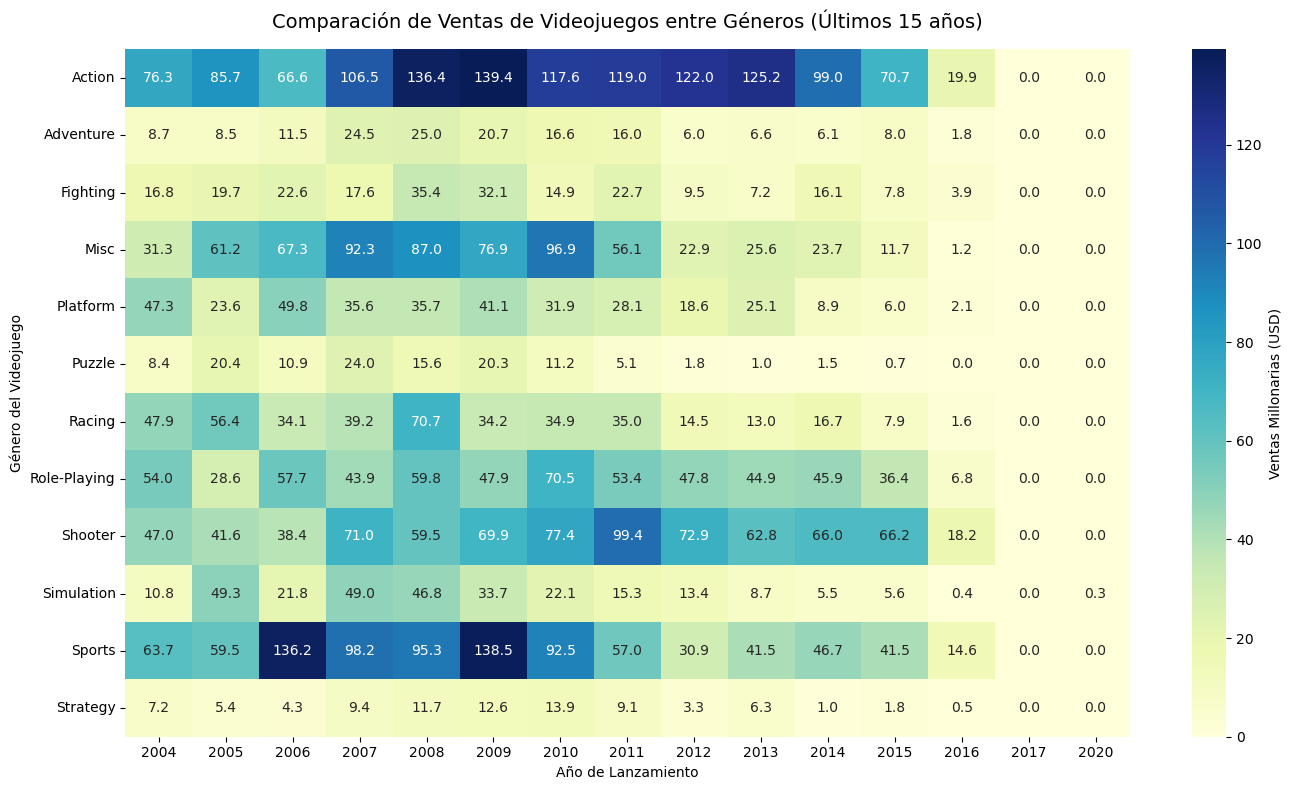

In [12]:
# GRAFICOS
pivot_generos = df_vg.pivot_table(index='Genre', columns='Year', values='Global_Sales', aggfunc='sum').fillna(0)
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_generos.iloc[:, -15:], annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Ventas Millonarias (USD)'})
plt.title('Comparación de Ventas de Videojuegos entre Géneros (Últimos 15 años)', fontsize=14, pad=15)
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Género del Videojuego')
plt.tight_layout()
plt.show()

In [17]:
# CRECIMIENTO ULTIMOS 4 AÑOS
años_recientes = sorted(df_vg['Year'].unique())[-4:]
print(f"Analizando ventana de crecimiento reciente: {años_recientes}\n")

df_reciente = df_vg[df_vg['Year'].isin(años_recientes)]

# 1. Crecimiento por Género
crecimiento_genero = df_reciente.pivot_table(index='Genre', columns='Year', values='Global_Sales', aggfunc='sum').fillna(0)
crecimiento_genero['Diferencia_Absoluta'] = crecimiento_genero[años_recientes[-1]] - crecimiento_genero[años_recientes[0]]
crecimiento_genero = crecimiento_genero.sort_values(by='Diferencia_Absoluta', ascending=False)

print("--- Crecimiento Neto por Género (Últimos 4 años) ---")
display(crecimiento_genero[['Diferencia_Absoluta']])

Analizando ventana de crecimiento reciente: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2020)]

--- Crecimiento Neto por Género (Últimos 4 años) ---


Year,Diferencia_Absoluta
Genre,
Puzzle,-0.70
Strategy,-1.82
Simulation,-5.33
Platform,-6.05
Fighting,-7.78
Racing,-7.92
Adventure,-8.03
Misc,-11.69
Role-Playing,-36.44


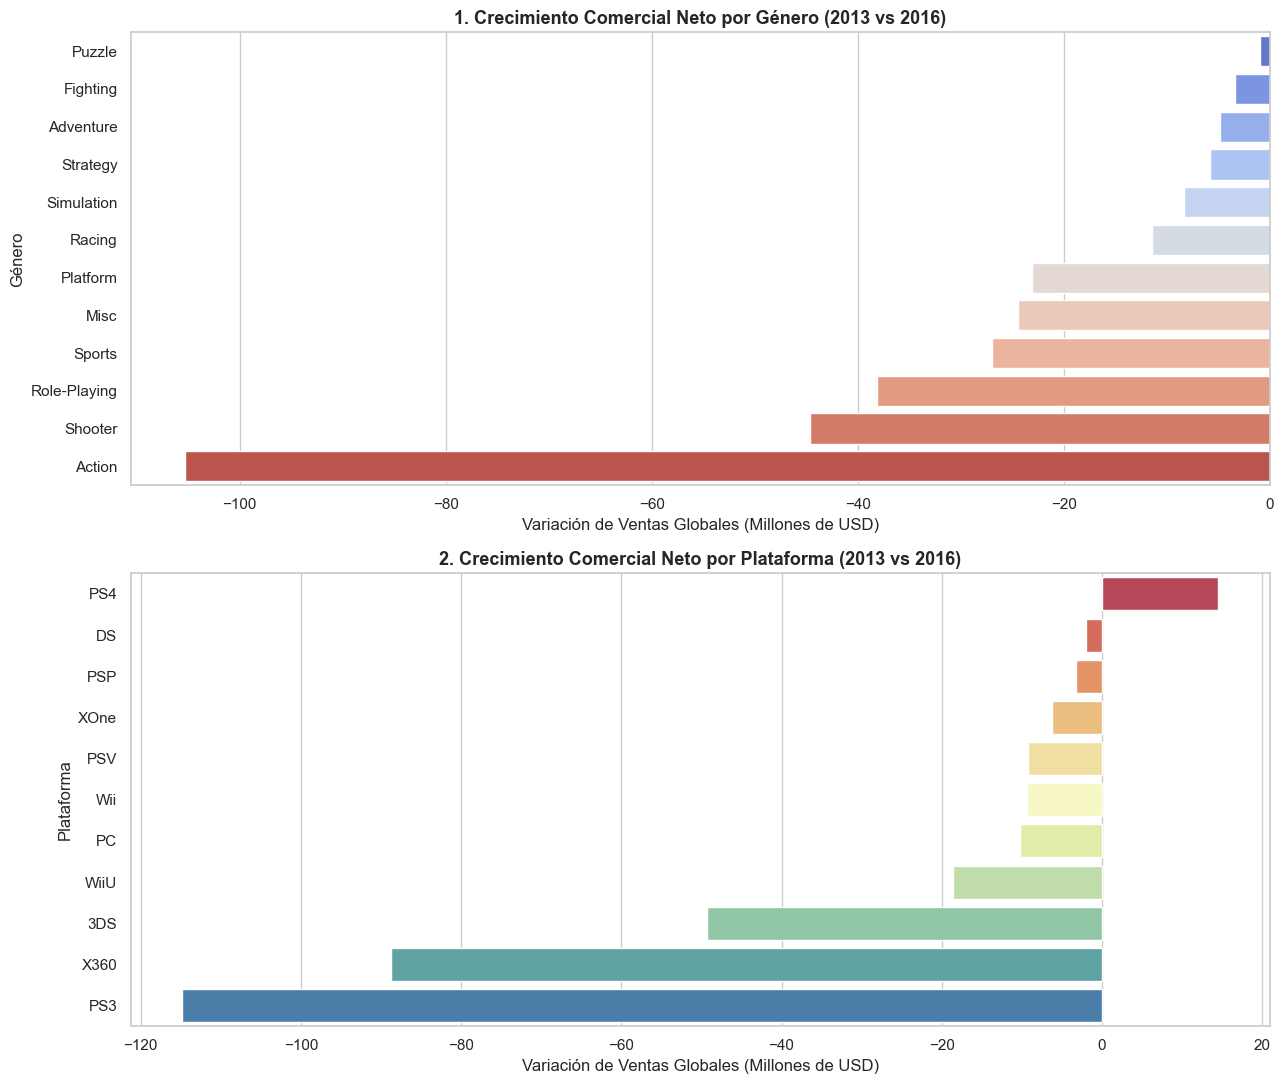

In [20]:
# GRAFICOS REPRESENTATIVOS DE CRECIMIENTO GENERO Y PLATAFORMA
df_vg = pd.read_csv('vgsales.csv')
df_vg['Year'] = pd.to_numeric(df_vg['Year'], errors='coerce')
df_reciente = df_vg[df_vg['Year'].isin([2013, 2014, 2015, 2016])].copy()

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(13, 11))

# --- GRÁFICA 1: CRECIMIENTO POR GÉNERO ---
pivot_gen = df_reciente.pivot_table(index='Genre', columns='Year', values='Global_Sales', aggfunc='sum').fillna(0)
# Calculamos la variación neta entre el año final (2016) y el año inicial (2013)
pivot_gen['Crecimiento'] = pivot_gen[2016] - pivot_gen[2013]
pivot_gen = pivot_gen.sort_values(by='Crecimiento', ascending=False)

sns.barplot(ax=axes[0], x=pivot_gen['Crecimiento'], y=pivot_gen.index, hue=pivot_gen.index, palette='coolwarm', legend=False)
axes[0].set_title('1. Crecimiento Comercial Neto por Género (2013 vs 2016)', fontsize=13, weight='bold')
axes[0].set_xlabel('Variación de Ventas Globales (Millones de USD)')
axes[0].set_ylabel('Género')

# --- GRÁFICA 2: CRECIMIENTO POR PLATAFORMA ---
pivot_plat = df_reciente.pivot_table(index='Platform', columns='Year', values='Global_Sales', aggfunc='sum').fillna(0)
pivot_plat['Crecimiento'] = pivot_plat[2016] - pivot_plat[2013]
pivot_plat = pivot_plat.sort_values(by='Crecimiento', ascending=False)

sns.barplot(ax=axes[1], x=pivot_plat['Crecimiento'], y=pivot_plat.index, hue=pivot_plat.index, palette='Spectral', legend=False)
axes[1].set_title('2. Crecimiento Comercial Neto por Plataforma (2013 vs 2016)', fontsize=13, weight='bold')
axes[1].set_xlabel('Variación de Ventas Globales (Millones de USD)')
axes[1].set_ylabel('Plataforma')

plt.tight_layout()
plt.show()

In [21]:

juego_reciente = df_reciente.groupby('Name')['Global_Sales'].sum().sort_values(ascending=False)
print("--- INSIGHTS DE CRECIMIENTO INDIVIDUAL PARA TUS SLIDES ---")
print(f"Videojuego Líder del Periodo: {juego_reciente.index[0]} con {juego_reciente.values[0]:.2f} MDD globales.")

--- INSIGHTS DE CRECIMIENTO INDIVIDUAL PARA TUS SLIDES ---
Videojuego Líder del Periodo: Grand Theft Auto V con 55.92 MDD globales.


Text(0, 0.5, 'Género')

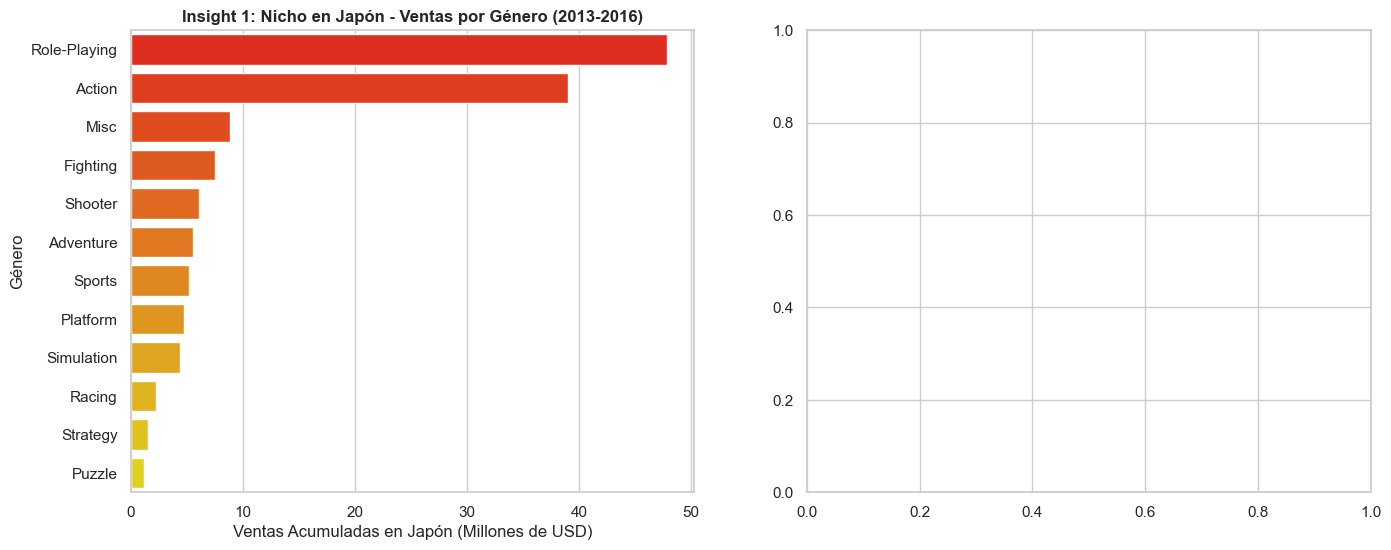

In [24]:
# OPORTUNIDADES DEL MERCADO
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
#OPORTUNIDAD EN EL MERCADO ASIÁTICO
top_jp = df_reciente.groupby('Genre')['JP_Sales'].sum().sort_values(ascending=False)
sns.barplot(ax=axes[0], x=top_jp.values, y=top_jp.index, hue=top_jp.index, palette='autumn', legend=False)
axes[0].set_title('Insight 1: Nicho en Japón - Ventas por Género (2013-2016)', fontsize=12, weight='bold')
axes[0].set_xlabel('Ventas Acumuladas en Japón (Millones de USD)')
axes[0].set_ylabel('Género')